# Notebook 2 - Actor-Critic (LONG-TERM) - self-contained

Chi import tu `Bert4Rec_model.py`. BERT (NB1) dong bang -> top-50 -> Actor-Critic sap lai day phim 4-5* (reward=graded NDCG rating). Actor init=BERT (san >= BERT). Chart actor/critic/val. Eval DCG so BERT.

In [1]:
import os, sys, json, math, random
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt
HERE = os.path.abspath("bert_ac_longterm") if os.path.isdir("bert_ac_longterm") else os.getcwd()
ROOT = os.path.dirname(HERE); sys.path.insert(0, ROOT)
from Bert4Rec_model import BERT4Rec, BERT4RecDataset, gather_indexes, train_one_epoch  # CHI import file model goc
import wandb
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 200
RATING_FILE = os.path.join(ROOT, "Data_Movielens_1m", "ml-1m", "ratings.dat")
ENV_FILE = os.path.join(ROOT, ".env")

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(42)

def load_env_key(p, key="wandb_api_key"):
    if not os.path.exists(p): return None
    for line in open(p, encoding="utf-8"):
        if "=" in line:
            k, v = line.split("=", 1)
            if k.strip() == key: return v.strip()
    return None
print("Device:", DEVICE)

Device: cuda


## Helpers (inline)

In [2]:
# ---- Time-split (no leakage): 20% cuoi/user = test ----
def load_and_split(rating_file, test_frac=0.2, min_len=5, max_len=MAX_LEN):
    cols = ["UserID", "MovieID", "Rating", "Timestamp"]
    df = pd.read_csv(rating_file, sep="::", engine="python", names=cols)
    df = df.sort_values(["UserID", "Timestamp"]).reset_index(drop=True)
    raw = sorted(df["MovieID"].unique()); m2i = {m: i + 1 for i, m in enumerate(raw)}; n_items = len(raw)
    df["enc"] = df["MovieID"].map(m2i); df["pair"] = list(zip(df["enc"], df["Rating"].astype(float)))
    seqs = df.groupby("UserID")["pair"].apply(list).to_dict()
    users = []; bseqs = []; ni = nt = nr = 0
    for _, seq in seqs.items():
        if len(seq) < min_len: continue
        n = len(seq); ts = max(1, round(test_frac * n)); rem = seq[:-ts]; test = seq[-ts:]
        if len(rem) < 2: continue
        rs = max(1, round(test_frac * len(rem))); rh = rem[:-rs]; rr = rem[-rs:]
        if len(rh) < 1: rh = rem[:1]; rr = rem[1:] or rem[-1:]
        ri = [m for m, r in rem][-max_len:]
        users.append({"hist_items": ri, "test_rel": {int(m): float(r) for m, r in test},
                      "rl_hist_items": [m for m, r in rh][-max_len:], "rl_rel": {int(m): float(r) for m, r in rr}})
        bseqs.append(ri); ni += n; nt += len(test); nr += len(rem)
    stats = {"n_users": len(users), "n_items": n_items, "n_interactions": int(ni), "n_train_remaining": int(nr),
             "n_test": int(nt), "avg_seq_len": round(ni / max(1, len(users)), 2),
             "avg_test_len": round(nt / max(1, len(users)), 2), "test_frac": test_frac, "max_len": max_len}
    return users, bseqs, n_items, m2i, stats

@torch.no_grad()
def encode_states(bert, hist_list, max_len=MAX_LEN, bs=256):
    bert.eval(); outs = []
    for i in range(0, len(hist_list), bs):
        chunk = hist_list[i:i + bs]; b = len(chunk)
        item_seq = torch.zeros((b, max_len), dtype=torch.long, device=DEVICE)
        slen = torch.zeros((b,), dtype=torch.long, device=DEVICE)
        for j, s in enumerate(chunk):
            L = min(len(s), max_len); slen[j] = max(L, 1)
            if L > 0: item_seq[j, :L] = torch.tensor(s[-L:], dtype=torch.long, device=DEVICE)
        so = bert.forward(bert.reconstruct_test_data(item_seq, slen)); outs.append(gather_indexes(so, slen - 1))
    return torch.cat(outs, 0)

# ---- Metrics (graded, gain = 2^rating - 1) ----
def dcg_at_k(r, rel, k):
    s = 0.0
    for i, it in enumerate(r[:k]):
        g = rel.get(int(it), 0.0)
        if g > 0: s += (2.0 ** g - 1.0) / math.log2(i + 2)
    return s
def ndcg_at_k(r, rel, k):
    ideal = sorted(rel.values(), reverse=True)
    idcg = sum((2.0 ** g - 1.0) / math.log2(i + 2) for i, g in enumerate(ideal[:k]))
    return dcg_at_k(r, rel, k) / idcg if idcg > 0 else 0.0
def recall_at_k(r, rel, k):
    return (sum(1 for it in r[:k] if int(it) in rel) / len(rel)) if rel else 0.0
def agg(ranks, rels, ks=(5, 10, 20)):
    m = {}
    for k in ks:
        m[f"DCG@{k}"] = float(np.mean([dcg_at_k(r, rl, k) for r, rl in zip(ranks, rels)]))
        m[f"NDCG@{k}"] = float(np.mean([ndcg_at_k(r, rl, k) for r, rl in zip(ranks, rels)]))
        m[f"Recall@{k}"] = float(np.mean([recall_at_k(r, rl, k) for r, rl in zip(ranks, rels)]))
    return m

@torch.no_grad()
def rank_bert(bert, users, target="test", subset=None, K=20):
    hk = "hist_items" if target == "test" else "rl_hist_items"
    rk = "test_rel" if target == "test" else "rl_rel"
    idx = list(range(len(users))) if subset is None else subset
    item_emb = bert.item_embedding.weight[:bert.n_items]; bias = bert.output_bias
    S = encode_states(bert, [users[i][hk] for i in idx]); ranks = []
    for i in range(0, S.shape[0], 256):
        sc = S[i:i + 256] @ item_emb.T + bias; sc[:, 0] = -1e9
        ranks += torch.topk(sc, K, 1).indices.cpu().numpy().tolist()
    return ranks, [users[i][rk] for i in idx]
print("[+] helpers ready")

[+] helpers ready


## 1. Time-split + nap BERT (NB1) dong bang

In [3]:
users, bert_seqs, n_real, movie2id, stats = load_and_split(RATING_FILE)
n_model = n_real + 1
json.dump(stats, open(os.path.join(HERE, "data_stats.json"), "w"), ensure_ascii=False, indent=2)
print(json.dumps(stats, ensure_ascii=False, indent=2))
bert = BERT4Rec(n_items=n_model, max_seq_length=MAX_LEN, hidden_size=64, n_layers=2, n_heads=2,
              hidden_dropout_prob=0.2, attn_dropout_prob=0.2, loss_type="CE").to(DEVICE)
bert.load_state_dict(torch.load(os.path.join(HERE, "bert4rec.pth"), map_location=DEVICE)); bert.eval()
for p in bert.parameters(): p.requires_grad = False
print("BERT loaded & frozen")

{
  "n_users": 6040,
  "n_items": 3706,
  "n_interactions": 1000209,
  "n_train_remaining": 800193,
  "n_test": 200016,
  "avg_seq_len": 165.6,
  "avg_test_len": 33.12,
  "test_frac": 0.2,
  "max_len": 200
}
BERT loaded & frozen


C:\Users\TanPhat\AppData\Local\Temp\ipykernel_15856\2234854171.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bert.load_state_dict(torch.load(os.path.join(HERE, "bert4r

## 2. Dinh nghia Actor-Critic (inline)

In [4]:
# ====== ACTOR-CRITIC (inline) - REINFORCE + value baseline, KHONG TD3/BC ======
class PolicyNet(nn.Module):
    """Actor additive: final = bert_logit + beta*delta(state,cand,logit_norm).
       Lop cuoi init=0 -> delta=0 -> thu tu khoi dau = BERT (san >= BERT)."""
    def __init__(self, dim, beta=1.0):
        super().__init__(); self.beta = beta
        self.net = nn.Sequential(nn.Linear(2 * dim + 1, 256), nn.ReLU(), nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1))
        nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)
    def forward(self, state, cand_emb, cand_logit):
        B, N, H = cand_emb.shape; s = state.unsqueeze(1).expand(-1, N, -1)
        mu = cand_logit.mean(1, keepdim=True); sd = cand_logit.std(1, keepdim=True).clamp(min=1e-6)
        feat = ((cand_logit - mu) / sd).unsqueeze(-1)
        delta = self.net(torch.cat([s, cand_emb, feat], -1)).squeeze(-1)
        return cand_logit + self.beta * delta

class ValueNet(nn.Module):   # Critic = value baseline
    def __init__(self, dim):
        super().__init__(); self.net = nn.Sequential(nn.Linear(dim, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, state): return self.net(state).squeeze(-1)

@torch.no_grad()
def bert_candidates(bert, states, topN):
    item_emb = bert.item_embedding.weight[:bert.n_items]; bias = bert.output_bias
    sc = states @ item_emb.T + bias; sc[:, 0] = -1e9
    top = torch.topk(sc, topN, 1)
    return top.indices, item_emb[top.indices], top.values

def cand_gains(cand_ids, rel_dicts):
    B, N = cand_ids.shape; g = np.zeros((B, N), dtype=np.float32); cid = cand_ids.cpu().numpy()
    for b in range(B):
        rel = rel_dicts[b]
        if not rel: continue
        for j in range(N):
            r = rel.get(int(cid[b, j]), 0.0)
            if r > 0: g[b, j] = 2.0 ** r - 1.0
    return torch.tensor(g)

@torch.no_grad()
def rank_ac(bert, actor, users, target="test", subset=None, topN=50):
    hk = "hist_items" if target == "test" else "rl_hist_items"; rk = "test_rel" if target == "test" else "rl_rel"
    idx = list(range(len(users))) if subset is None else subset
    S = encode_states(bert, [users[i][hk] for i in idx]); ranks = []
    for i in range(0, S.shape[0], 256):
        st = S[i:i + 256]; cand_ids, cand_emb, cand_logit = bert_candidates(bert, st, topN)
        order = torch.argsort(actor(st, cand_emb, cand_logit), 1, descending=True)
        ranks += torch.gather(cand_ids, 1, order).cpu().numpy().tolist()
    return ranks, [users[i][rk] for i in idx]

def val_dcg10(bert, actor, users, subset, topN=50):
    rk, rl = rank_ac(bert, actor, users, target="rl", subset=subset, topN=topN)
    return float(np.mean([dcg_at_k(r, x, 10) for r, x in zip(rk, rl)]))

def train_ac(bert, users, epochs=30, bs=512, topN=50, K=10, lr=1e-4, patience=8, run=None):
    dim = bert.hidden_size
    actor = PolicyNet(dim).to(DEVICE); critic = ValueNet(dim).to(DEVICE)
    aopt = optim.Adam(actor.parameters(), lr); copt = optim.Adam(critic.parameters(), lr)
    disc = (1.0 / torch.log2(torch.arange(K, device=DEVICE).float() + 2)).unsqueeze(0)
    rl_rel = [u["rl_rel"] for u in users]
    S = encode_states(bert, [u["rl_hist_items"] for u in users]).cpu(); N = S.shape[0]
    val_sub = list(range(0, N, max(1, N // 2000)))[:2000]
    hist = {"actor": [], "critic": [], "val_dcg10": [], "train_reward": []}
    base = val_dcg10(bert, actor, users, val_sub, topN); print(f"[AC] VAL DCG@10 init(=BERT)={base:.4f}")
    best, best_sd, noimp = base, {k: v.detach().clone() for k, v in actor.state_dict().items()}, 0
    for ep in range(epochs):
        actor.train(); critic.train(); perm = np.random.permutation(N); ea = ec = er = 0.0; nb = 0
        for i in range(0, N, bs):
            bidx = perm[i:i + bs]; st = S[bidx].to(DEVICE); rels = [rl_rel[j] for j in bidx]
            cand_ids, cand_emb, cand_logit = bert_candidates(bert, st, topN)
            gains = cand_gains(cand_ids, rels).to(DEVICE); scores = actor(st, cand_emb, cand_logit)
            avail = torch.ones_like(scores, dtype=torch.bool); logp = torch.zeros(scores.shape[0], device=DEVICE)
            cg = torch.zeros(scores.shape[0], K, device=DEVICE)
            for t in range(K):
                m = torch.distributions.Categorical(F.softmax(scores.masked_fill(~avail, -1e9), -1))
                a = m.sample(); logp = logp + m.log_prob(a); cg[:, t] = gains.gather(1, a.unsqueeze(1)).squeeze(1)
                avail.scatter_(1, a.unsqueeze(1), False)
            dcg = (cg * disc).sum(1); ideal, _ = torch.sort(gains, 1, descending=True)
            idcg = (ideal[:, :K] * disc).sum(1).clamp(min=1e-8); reward = dcg / idcg
            V = critic(st); adv = (reward - V).detach()
            aloss = -(adv * logp).mean(); closs = F.mse_loss(V, reward)
            aopt.zero_grad(); aloss.backward(); aopt.step()
            copt.zero_grad(); closs.backward(); copt.step()
            ea += aloss.item(); ec += closs.item(); er += reward.mean().item(); nb += 1
        va, vc, vr = ea / nb, ec / nb, er / nb; vd = val_dcg10(bert, actor, users, val_sub, topN)
        for k_, v_ in [("actor", va), ("critic", vc), ("train_reward", vr), ("val_dcg10", vd)]: hist[k_].append(v_)
        print(f"[AC] ep {ep+1:02d}/{epochs}  actor={va:.4f} critic={vc:.4f} reward={vr:.4f}  VAL DCG@10={vd:.4f}" + ("  <- best" if vd > best + 1e-6 else f" (best {best:.4f},{noimp+1}/{patience})"))
        if run:
            try: run.log({"ac/actor_loss": va, "ac/critic_loss": vc, "ac/train_reward": vr, "ac/val_dcg10": vd, "ac/epoch": ep + 1})
            except Exception: pass
        if vd > best + 1e-6: best = vd; best_sd = {k: v.detach().clone() for k, v in actor.state_dict().items()}; noimp = 0
        else:
            noimp += 1
            if noimp >= patience: print(f"[AC] EARLY STOP ep {ep+1}, best={best:.4f} (BERT init={base:.4f})"); break
    actor.load_state_dict(best_sd); return actor, hist, base
print("[+] Actor-Critic defined")

[+] Actor-Critic defined


## 3. Train Actor-Critic long-term (+ wandb)

In [5]:
key = load_env_key(ENV_FILE); run = None
try:
    if key: wandb.login(key=key)
    run = wandb.init(project="bert4rec-ac-longterm", name="actor-critic-longterm", reinit=True)
except Exception as e: print("wandb off:", e)
actor, hist, base = train_ac(bert, users, epochs=30, bs=512, topN=50, K=10, patience=8, run=run)
torch.save(actor.state_dict(), os.path.join(HERE, "actor_longterm.pth"))
if run:
    try: run.finish()
    except Exception: pass
print("saved actor_longterm.pth | BERT-init VAL DCG@10 =", round(base, 4))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.


wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\TanPhat\_netrc


wandb: Currently logged in as: lamgiang (lamgiang-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


...

wandb: uploading history steps 0-7, summary, console lines 0-9


wandb: 
wandb: Run history:
wandb:   ac/actor_loss ▁▇█▇▆▇▇▇
wandb:  ac/critic_loss █▂▂▁▁▁▁▁
wandb:        ac/epoch ▁▂▃▄▅▆▇█
wandb: ac/train_reward ▁█▇▄▅▅█▇
wandb:    ac/val_dcg10 ▄▄▄▄▄██▁
wandb: 
wandb: Run summary:
wandb:   ac/actor_loss -0.03842
wandb:  ac/critic_loss 0.02349
wandb:        ac/epoch 8
wandb: ac/train_reward 0.07827
wandb:    ac/val_dcg10 4.0845
wandb: 


wandb:  View run actor-critic-longterm at: https://wandb.ai/lamgiang-fpt-university/bert4rec-ac-longterm/runs/7aiczs8x
wandb:  View project at: https://wandb.ai/lamgiang-fpt-university/bert4rec-ac-longterm
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260619_212532-7aiczs8x\logs


saved actor_longterm.pth | BERT-init VAL DCG@10 = 4.0847


## 4. Chart: Actor loss / Critic loss / VAL DCG@10 (duong BERT = san)

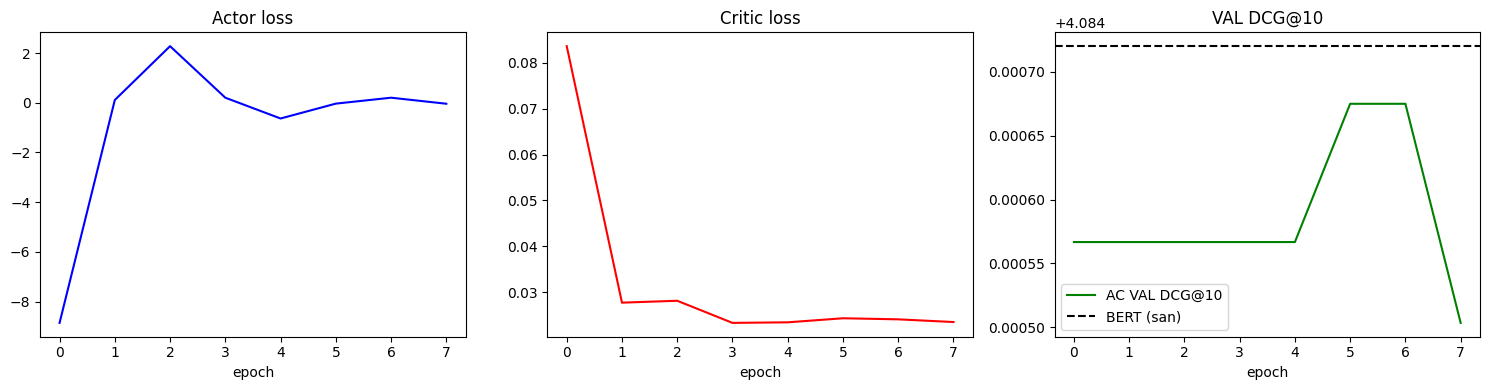

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(hist["actor"], color="blue"); ax[0].set_title("Actor loss"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["critic"], color="red"); ax[1].set_title("Critic loss"); ax[1].set_xlabel("epoch")
ax[2].plot(hist["val_dcg10"], color="green", label="AC VAL DCG@10"); ax[2].axhline(base, ls="--", color="black", label="BERT (san)")
ax[2].set_title("VAL DCG@10"); ax[2].set_xlabel("epoch"); ax[2].legend()
plt.tight_layout(); plt.show()

## 5. Eval DCG: BERT vs BERT+Actor-Critic (TEST, long-term)

In [7]:
rb, rl = rank_bert(bert, users, target="test", K=20); res_bert = agg(rb, rl)
ra, rl2 = rank_ac(bert, actor, users, target="test", topN=50); res_ac = agg(ra, rl2)
results = {"data_stats": stats, "BERT (short-term)": res_bert, "BERT + Actor-Critic (long-term)": res_ac}
json.dump(results, open(os.path.join(HERE, "results.json"), "w"), ensure_ascii=False, indent=2)
COLS = ["DCG@5", "DCG@10", "DCG@20", "NDCG@10", "Recall@10"]
print(f"{'Model':<32}" + "".join(f"{c:>11}" for c in COLS)); print("-" * (32 + 11 * len(COLS)))
for name, m in [("BERT (short-term)", res_bert), ("BERT+Actor-Critic (long-term)", res_ac)]:
    print(f"{name:<32}" + "".join(f"{m[c]:>11.4f}" for c in COLS))

Model                                 DCG@5     DCG@10     DCG@20    NDCG@10  Recall@10
---------------------------------------------------------------------------------------
BERT (short-term)                    2.7359     3.9998     6.3018     0.0367     0.0220
BERT+Actor-Critic (long-term)        2.7359     3.9998     6.3018     0.0367     0.0220
